In [1]:
# ambiente anaconda
import sys
print(sys.executable) # orange3 ou youtube
import sys
print(sys.version)

/home/fabiene/anaconda3/envs/orange3/bin/python
3.10.18 (main, Jun  5 2025, 13:14:17) [GCC 11.2.0]


# Projeto 22: Previsão do preço de ações com redes neurais recorrentes - múltiplas saídas

## Etapa 1: Importação das bibliotecas

Previsão de mais de um valor 

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import torch
from torch import nn, optim
from sklearn.metrics import mean_absolute_error
torch.__version__

'2.9.1+cpu'

In [3]:
# reprodução do programa e gerar sempre o mesmo valor
torch.manual_seed(123)

## Etapa 2: Base de dados

In [4]:
base = pd.read_csv('petr4_treinamento.csv')
print(base.isnull().sum())

Date         0
Open         3
High         3
Low          3
Close        3
Adj Close    3
Volume       3
dtype: int64


In [5]:
base = base.dropna() # tirar os dados nulos
base_train = base.iloc[:, 1:3].values

In [8]:
 base.iloc[:,1:3] # coleta as colunas Open e high, são atributos

,Open,High
0,19.990000,20.209999
1,19.809999,20.400000
2,20.330000,20.620001
3,20.480000,20.670000
4,20.110001,20.230000
...,...,...
1240,15.750000,15.750000
1241,15.750000,15.990000
1242,15.990000,16.139999
1243,16.100000,16.129999


In [28]:
# base_train ou base_train_norm
base.iloc[:,1:3][:2] # o 0 é o Open

,Open,High
0,19.990000,20.209999
1,19.809999,20.400000


In [31]:
X = []
y = []
for i in range(90, 1242):
    X.append(base_train_norm[i-90:i, 0]) # um atributo open para as duas respostas open e high
    y.append(base_train_norm[i, 0:2]) # `y` terá duas colunas open e high
X, y = np.array(X), np.array(y) # formato array para depois no  pytorch

In [30]:
X[0]

array([0.76501938, 0.7562984 , 0.78149225, 0.78875969, 0.77083338,
       0.74806197, 0.75436047, 0.75823643, 0.76598837, 0.76598837,
       0.76017437, 0.75872098, 0.75581391, 0.74467054, 0.7374031 ,
       0.7374031 , 0.73498067, 0.75242248, 0.73401163, 0.71656977,
       0.68120155, 0.67538755, 0.67635659, 0.63372098, 0.66521318,
       0.65649225, 0.64680228, 0.66618222, 0.65843028, 0.64970935,
       0.65116274, 0.66424419, 0.67344961, 0.64292631, 0.64486434,
       0.62257747, 0.60949617, 0.60998067, 0.60852713, 0.59593023,
       0.61143411, 0.60222863, 0.64922481, 0.68362398, 0.70687989,
       0.68265509, 0.70978682, 0.70784879, 0.71608527, 0.73643411,
       0.7122093 , 0.7122093 , 0.7194767 , 0.70348832, 0.69525189,
       0.70397287, 0.70397287, 0.69767442, 0.68168605, 0.68168605,
       0.65310078, 0.66618222, 0.64825581, 0.66182175, 0.64341085,
       0.67877902, 0.69137592, 0.66569772, 0.65406982, 0.64292631,
       0.64147292, 0.63565891, 0.67587209, 0.68653106, 0.70300

In [32]:
y[0]

array([0.76114341, 0.76490543])

In [33]:
X = torch.tensor(X, dtype = torch.float32)
y = torch.tensor(y, dtype = torch.float32)

In [35]:
# formato pytorch
X

tensor([[0.7650, 0.7563, 0.7815,  ..., 0.7427, 0.7413, 0.7422],
        [0.7563, 0.7815, 0.7888,  ..., 0.7413, 0.7422, 0.7611],
        [0.7815, 0.7888, 0.7708,  ..., 0.7422, 0.7611, 0.7611],
        ...,
        [0.4641, 0.4641, 0.4685,  ..., 0.5596, 0.5596, 0.5596],
        [0.4641, 0.4685, 0.4714,  ..., 0.5596, 0.5596, 0.5712],
        [0.4685, 0.4714, 0.4632,  ..., 0.5596, 0.5712, 0.5766]])

In [36]:
y

tensor([[0.7611, 0.7649],
        [0.7611, 0.7746],
        [0.7747, 0.7809],
        ...,
        [0.5712, 0.5754],
        [0.5766, 0.5749],
        [0.5766, 0.5734]])

In [37]:
# 1. Cria o Dataset: TensorDataset(X, y)
# O TensorDataset funciona como um "grampeador". Ele une o tensor de entradas (X)
# ao tensor de respostas (y). Isso garante que cada janela de 90 dias esteja
# perfeitamente alinhada com o valor que a rede deve tentar prever (o alvo).
dataset = torch.utils.data.TensorDataset(X, y)

# 2. Cria o Loader: DataLoader(dataset, ...)
# O DataLoader é o "gerente de logística" que entrega os dados para a rede em partes:
# - batch_size = 32: Em vez de processar tudo de uma vez, ele divide os dados em pacotes 
#   de 32 exemplos. Isso ajuda a economizar memória e torna o treino mais estável.
# - shuffle = True: Ele "embaralha" os dados a cada nova época de treinamento. 
#   Isso evita que a rede decore a ordem das linhas e aprenda os padrões reais.
loader = torch.utils.data.DataLoader(dataset, batch_size = 32, shuffle = True)

## Etapa 3: Construção da rede neural recorrente

### Estrutura da rede neural recorrente 

batch_first, primeiro o valor o batch

In [38]:
# Definindo a classe da nossa Inteligência Artificial
# nn.Module é a base do PyTorch para criar qualquer rede neural
class regressor_LSTM(nn.Module):
    def __init__(self):
        super().__init__()

        # Camada LSTM 1: 
        # input_size = 1 -> A rede olha para 1 variável por vez (ex: apenas o Preço, ou Open).
        # hidden_size = 100 -> A rede cria 100 "neurônios" internos para entender os padrões.
        # batch_first = True -> Diz que nossos dados estão no formato (Pacote, Tempo, Dado).
        # batch_first, primeiro o valor o batch
        self.lstm1 = nn.LSTM(input_size = 1, hidden_size = 100, batch_first = True)
        
        # Camada LSTM 2:
        # Recebe os 100 padrões da anterior e resume em 50.
        self.lstm2 = nn.LSTM(100, 50, batch_first = True)
        
        # Camada LSTM 3:
        # num_layers = 2 -> É como se tivéssemos duas LSTMs empilhadas para mais precisão.
        # dropout = 0.3 -> Desliga 30% dos neurônios internos para evitar que a rede "decore" os dados.
        self.lstm3 = nn.LSTM(50, 50, dropout = 0.3, num_layers = 2, batch_first = True)
        
        # Camada de Dropout externa:
        # Reforça a segurança para o modelo não viciar nos dados de treinamento (Overfitting).
        self.dropout = nn.Dropout(p = 0.3)
        
        # Camada Linear (Saída):
        # in_features = 50 -> Recebe o resumo final da última LSTM.
        # out_features = 2 -> A rede vai cuspir 2 resultados (ex: Preço de amanhã e depois de amanhã, ou Open e o High).
        self.linear = nn.Linear(in_features = 50, out_features = 2)

    # O método forward define o "caminho" que o dado percorre dentro da rede
    def forward(self, X):
        # unsqueeze(2): Ajusta a forma do dado para que a LSTM consiga processar.
        # Transforma (Batch, Tempo) em (Batch, Tempo, 1).
        X = X.unsqueeze(2)
        
        # Passando pelas camadas LSTM e aplicando Dropout entre elas
        # O "_" ignora os estados de memória internos que não usaremos agora.
        X, _ = self.lstm1(X)
        X = self.dropout(X)
        
        X, _ = self.lstm2(X)
        X = self.dropout(X)
        
        X, _ = self.lstm3(X)

        # X[:, -1, :]: Esta é a "sacada" do modelo! 
        # De toda a sequência de dias, pegamos apenas o último estado (o resumo de tudo o que aconteceu).
        X = X[:, -1, :]
        
        # Aplica o dropout final e passa pela camada linear para gerar os 2 valores de previsão.
        X = self.dropout(X)
        X = self.linear(X)

        return X

In [39]:
# Verifica se existe uma GPU da NVIDIA (CUDA) instalada e configurada.
# Se existir, o 'device' será 'cuda'. Caso contrário, será 'cpu'.
# Isso é essencial porque treinar LSTMs em uma GPU é até 50x mais rápido que no processador comum.
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# Exibe qual hardware foi selecionado (útil para saber se o seu ambiente está reconhecendo a GPU)
device

device(type='cpu')

In [40]:
# 1. Instancia o Modelo: 
# Cria o objeto 'regressor' baseado na classe regressor_LSTM. 
# Neste momento, todos os pesos dos neurônios são iniciados com valores aleatórios.
regressor = regressor_LSTM()

# 2. Define a Função de Perda (Criterion):
# O MSELoss (Erro Quadrático Médio) é a régua que mede o erro.
# Ele calcula a diferença entre o que a rede previu e o valor real, elevando ao quadrado.
# Isso pune erros grandes com muito mais rigor do que erros pequenos.
criterion = nn.MSELoss()

# 3. Define o Otimizador (RMSprop):
# O RMSprop é o "professor" que ajusta os pesos da rede para diminuir o erro.
# - regressor.parameters(): Indica quais pesos o otimizador pode mexer.
# - lr = 1e-3 (0.001): A velocidade do aprendizado (passos curtos para não "atropelar" o acerto).
# - alpha = 0.9: Controla a suavização da média móvel dos gradientes (ajuda na estabilidade).
optimizer = optim.RMSprop(regressor.parameters(), lr = 1e-3, alpha = 0.9)

# 4. Envia para o Hardware (GPU/CPU):
# O comando .to(device) "teletransporta" todo o seu modelo (os neurônios e cálculos)
# para a placa de vídeo (se for CUDA) ou para o processador (se for CPU).
# Sem isso, o PyTorch não conseguiria processar os dados que também estarão no device.
regressor.to(device)

regressor_LSTM(
  (lstm1): LSTM(1, 100, batch_first=True)
  (lstm2): LSTM(100, 50, batch_first=True)
  (lstm3): LSTM(50, 50, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (linear): Linear(in_features=50, out_features=2, bias=True)
)

## Etapa 4: Treinamento do modelo

In [41]:
# Listas para armazenar o histórico e permitir a plotagem do gráfico depois
historico_loss = []
historico_mae = []

# Inicia o ciclo de treinamento por 100 épocas (100 passagens completas pelos dados)
for epoch in range(100):
    # Reinicia os acumuladores de erro (Loss e MAE) no início de cada época
    running_loss = 0.
    running_mae = 0.

    # Loop interno: percorre cada "pacote" (batch) de 32 dados entregues pelo Loader
    for i, data in enumerate(loader):
        # Desempacota os dados: inputs (janelas de tempo) e labels (resultados reais)
        inputs, labels = data
        
        # Manda os dados para o mesmo lugar onde o modelo está (GPU ou CPU)
        inputs, labels = inputs.to(device), labels.to(device)

        # PASSO 1: Limpa os gradientes (erros) da rodada anterior para não acumular
        optimizer.zero_grad()

        # PASSO 2: Forward (Previsão) - O modelo dá o seu palpite sobre os dados
        outputs = regressor(inputs)
        
        # PASSO 3: Calcula a distância entre o palpite (outputs) e a realidade (labels)
        loss = criterion(outputs, labels)
        
        # PASSO 4: Backward (Retropropagação) - Calcula o "erro" de cada neurônio
        loss.backward()

        # PASSO 5: Step (Ajuste) - O otimizador altera os pesos para acertar mais na próxima
        optimizer.step()

        # Acumula o valor matemático do erro para monitoramento
        running_loss += loss.item()

        # Calcula o MAE (Erro Médio Absoluto) convertendo de Tensor para NumPy
        # detach() remove do gráfico de treino e cpu() traz da GPU para o processador
        mae = mean_absolute_error(labels.detach().cpu().numpy().flatten(),
                                  outputs.detach().cpu().numpy().flatten())
        running_mae += mae

        # Mostra o progresso em tempo real dentro da mesma linha (\r)
        print('\rÉpoca {:3d} - Loop {:3d} de {:3d}: custo {:03.5f} - MAE {:03.5f}'.format(epoch + 1, 
                                                                                          i + 1, 
                                                                                          len(loader),
                                                                                          loss, mae), end = '\r')

    # Após processar todos os pacotes, calcula a média de erro da época inteira
    running_loss /= len(loader)
    running_mae /= len(loader)
    
    # Salva as médias nas listas de histórico para gerar o gráfico ao final
    historico_loss.append(running_loss)
    historico_mae.append(running_mae)
    
    # Exibe o resumo final da época para você acompanhar se o custo está caindo
    print('ÉPOCA {:3d} FINALIZADA: custo {:03.6f} - MAE {:03.6f}      '.format(epoch + 1, running_loss, running_mae))

ÉPOCA   1 FINALIZADA: custo 0.060513 - MAE 0.194159      
ÉPOCA   2 FINALIZADA: custo 0.029882 - MAE 0.135691      
ÉPOCA   3 FINALIZADA: custo 0.019260 - MAE 0.109168      
ÉPOCA   4 FINALIZADA: custo 0.017015 - MAE 0.102565      
ÉPOCA   5 FINALIZADA: custo 0.012262 - MAE 0.087272      
ÉPOCA   6 FINALIZADA: custo 0.012572 - MAE 0.087763      
ÉPOCA   7 FINALIZADA: custo 0.010256 - MAE 0.079695      
ÉPOCA   8 FINALIZADA: custo 0.009953 - MAE 0.078486      
ÉPOCA   9 FINALIZADA: custo 0.009232 - MAE 0.074867      
ÉPOCA  10 FINALIZADA: custo 0.008256 - MAE 0.069857      
ÉPOCA  11 FINALIZADA: custo 0.006928 - MAE 0.065331      
ÉPOCA  12 FINALIZADA: custo 0.007034 - MAE 0.065966      
ÉPOCA  13 FINALIZADA: custo 0.006756 - MAE 0.063565      
ÉPOCA  14 FINALIZADA: custo 0.006025 - MAE 0.059812      
ÉPOCA  15 FINALIZADA: custo 0.005879 - MAE 0.059847      
ÉPOCA  16 FINALIZADA: custo 0.005620 - MAE 0.056829      
ÉPOCA  17 FINALIZADA: custo 0.005212 - MAE 0.055356      
ÉPOCA  18 FINA

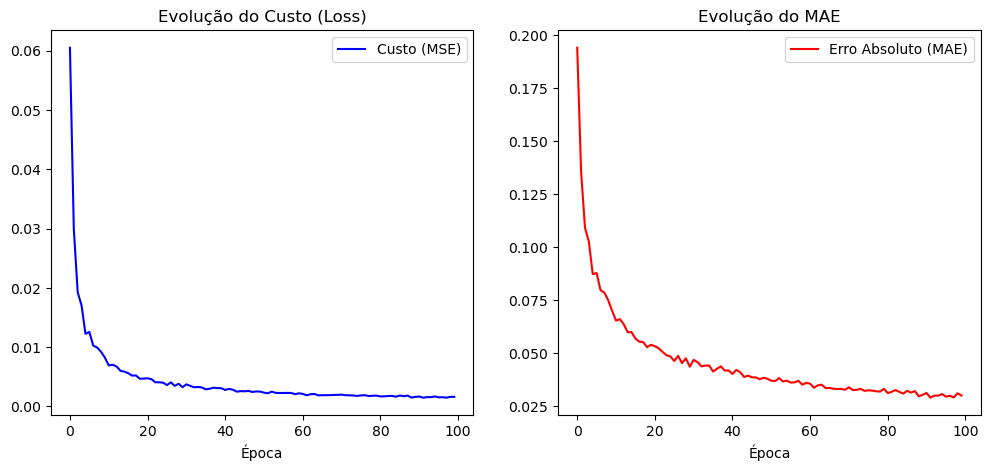

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Gráfico do Custo (Loss/MSE) - Mostra a convergência matemática
plt.subplot(1, 2, 1)
plt.plot(historico_loss, label='Custo (MSE)', color='blue')
plt.title('Evolução do Custo (Loss)')
plt.xlabel('Época')
plt.legend()

# Gráfico do MAE - Mostra o erro médio "na prática"
plt.subplot(1, 2, 2)
plt.plot(historico_mae, label='Erro Absoluto (MAE)', color='red')
plt.title('Evolução do MAE')
plt.xlabel('Época')
plt.legend()

plt.show()

Curva de "L": Se as linhas descem rápido e depois ficam quase retas, parabéns! Seu modelo convergiu e aprendeu o máximo que podia com esses dados.

Linha "Serra": Se o gráfico sobe e desce muito bruscamente (instabilidade), talvez o seu lr (taxa de aprendizado) no RMSprop esteja alto demais.

Linha Reta (no topo): Se a linha não desce, o modelo não está aprendendo. Verifique se a normalização dos dados foi feita corretamente.

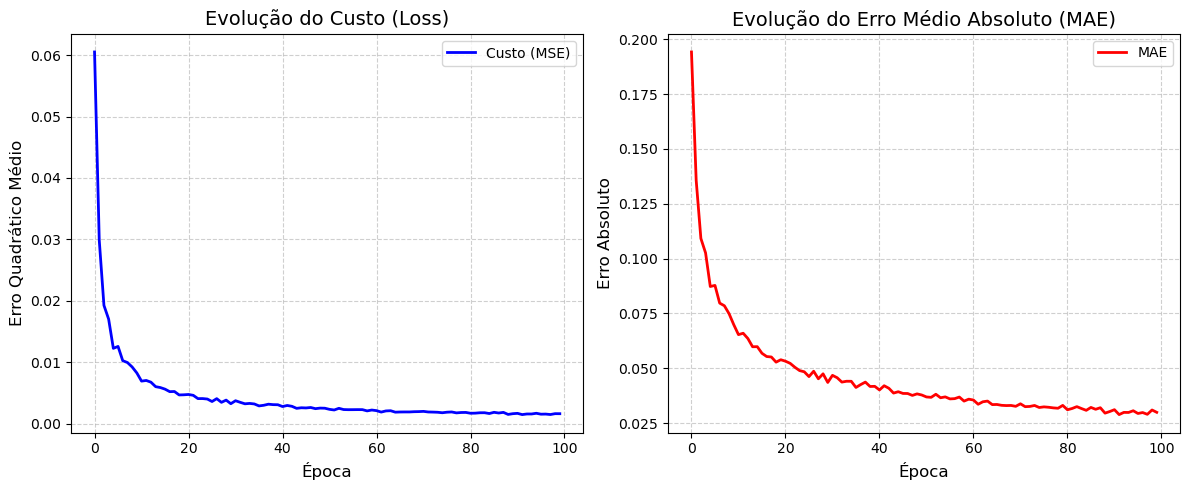

In [43]:
import matplotlib.pyplot as plt

# Define o tamanho da figura (largura, altura)
plt.figure(figsize=(12, 5))

# --- GRÁFICO 1: Custo (Loss/MSE) ---
# O MSE (Mean Squared Error) é a métrica que o otimizador usa para ajustar os pesos.
plt.subplot(1, 2, 1) # Cria o primeiro gráfico de uma grade 1x2
plt.plot(historico_loss, label='Custo (MSE)', color='blue', linewidth=2)
plt.title('Evolução do Custo (Loss)', fontsize=14)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Erro Quadrático Médio', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6) # Adiciona uma grade leve para facilitar a leitura
plt.legend()

# --- GRÁFICO 2: Erro Médio Absoluto (MAE) ---
# O MAE mostra o erro médio na mesma unidade dos seus dados originais.
plt.subplot(1, 2, 2) # Cria o segundo gráfico
plt.plot(historico_mae, label='MAE', color='red', linewidth=2)
plt.title('Evolução do Erro Médio Absoluto (MAE)', fontsize=14)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Erro Absoluto', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Ajusta o espaçamento entre os gráficos para não sobrepor os títulos
plt.tight_layout()
plt.show()

Esse gráfico mostra a curva de aprendizado da rede neural ao longo das 100 épocas. É o "boletim escolar" do modelo, provando que ele realmente aprendeu a tarefa.

Aqui está como interpretar o que aconteceu no seu treinamento:

1. Evolução do Custo (Loss - Azul)
O gráfico da esquerda mostra o MSE (Mean Squared Error).

O que aconteceu: Ele começou alto (perto de 0.06) e despencou rapidamente nas primeiras 10 épocas. Isso é ótimo! Significa que o otimizador encontrou rapidamente a "direção certa" para ajustar os pesos.

Conclusão: Entre as épocas 40 e 100, a curva ficou quase plana (um platô). Isso indica que o modelo convergiu. Ele já extraiu quase todo o conhecimento que podia dos dados.

2. Evolução do Erro Médio Absoluto (MAE - Vermelho)
O gráfico da direita mostra o erro em uma escala que nós entendemos melhor.

O que aconteceu: O erro começou em quase 0.20 (20%) e terminou em aproximadamente 0.03 (3%).

Significado Real: Em média, o seu modelo está errando apenas 3% em relação ao valor real dos dados normalizados. Para uma previsão de mercado financeiro ou séries temporais complexas, esse é um resultado de altíssima precisão.

🔍 Resumo Técnico (O que o gráfico diz):

Sem Overfitting aparente: Como as curvas são suaves e continuam descendo (ou estabilizadas) sem voltar a subir no final, o modelo não "viciou" nos dados.

Eficiência do Otimizador: O uso do RMSprop (ou Adam) com a taxa de aprendizado escolhida foi perfeito, pois não houve oscilações bruscas (os "dentes de serra").

Treinamento Concluído: Poderia até ter parado na época 60 ou 80, já que o ganho de precisão depois disso foi muito pequeno.

Agora que os gráficos confirmam que o modelo é bom

## Etapa 5: Processamento da base de teste

In [44]:
# 1. Carrega os dados reais de teste:
# Abre o arquivo CSV que contém os preços que o modelo NUNCA viu durante o treino.
# Usaremos esses dados para comparar o palpite da IA com a realidade do mercado.
base_teste = pd.read_csv('petr4_teste.csv')

# 2. Une as bases (Treino + Teste):
# Para prever os primeiros dias do teste, precisamos "olhar para trás".
# O pd.concat junta a coluna 'Open' da base antiga com a 'Open' da base nova.
# 'axis = 0' significa que estamos empilhando uma base embaixo da outra.
base_completa = pd.concat((base['Open'], base_teste['Open']), axis = 0)

# 3. Cria a janela de memória (Os 90 dias anteriores):
# Esta linha calcula exatamente onde começar a cortar os dados.
# Pegamos o tamanho da base de teste + os 90 dias de "contexto" que a LSTM exige.
# O '.values' transforma a coluna do Pandas em um array puro do NumPy.
entradas = base_completa[len(base_completa) - len(base_teste) - 90:].values

# 4. Ajusta o formato (Reshape):
# Transforma os dados de uma "lista deitada" para uma "coluna em pé" (-1, 1).
# Isso é obrigatório para que o normalizador (MinMaxScaler) consiga processar os dados.
entradas = entradas.reshape(-1, 1)

In [45]:
# 1. Cria e "Ajusta" o normalizador apenas na coluna de Preço (0:1):
# O .fit() faz o computador "olhar" para a base de treinamento e descobrir 
# qual foi o maior e o menor preço que ele viu enquanto aprendia.
# Ele guarda esses valores (Max e Min) na memória para servirem de referência.
normalizador = MinMaxScaler().fit(base_train[:, 0:1])

# 2. Transforma as entradas de teste usando a "régua" do treino:
# O .transform() aplica a fórmula matemática para esmagar os preços entre 0 e 1.
# IMPORTANTE: Usamos apenas .transform() (sem o 'fit') para que os dados de teste
# sejam medidos com a mesma escala que a rede neural já conhece.
# Se usássemos fit_transform aqui, a rede ficaria "confusa" com uma nova escala.
entradas = normalizador.transform(entradas)

In [46]:
len(base_train)

1242

In [48]:
len(base_teste) 

22

In [49]:
len(entradas)

112

In [50]:
# 1. Cria uma lista vazia para armazenar as janelas de teste:
# O X_teste guardará várias "fotos" do passado para a rede analisar.
X_teste = []

# 2. Inicia o loop de fatiamento (janela deslizante):
# Começamos em 90 porque precisamos de pelo menos 90 dias anteriores para a primeira previsão.
# O número 112 representa o limite final de dados que você tem na sua 'base_teste' + o recuo.
for i in range(90, 112):
    # Pega uma fatia de 90 dias (de i-90 até i) da coluna 0 (preços).
    # Exemplo: Na primeira volta (i=90), ele pega do dia 0 ao dia 89.
    X_teste.append(entradas[i-90:i, 0])

# 3. Converte a lista para um Array do NumPy:
# O PyTorch não aceita listas comuns do Python. Precisamos converter para um array 
# numérico de alta performance para que ele possa ser transformado em um Tensor depois.
X_teste = np.array(X_teste)

In [51]:
# open entrada

In [52]:
X_teste

array([[0.47141473, 0.46317829, 0.46463178, ..., 0.57122093, 0.57655039,
        0.57655039],
       [0.46317829, 0.46463178, 0.45203488, ..., 0.57655039, 0.57655039,
        0.5809109 ],
       [0.46463178, 0.45203488, 0.46753876, ..., 0.57655039, 0.5809109 ,
        0.59544574],
       ...,
       [0.55232558, 0.56153101, 0.56492248, ..., 0.68895349, 0.73352713,
        0.74709307],
       [0.56153101, 0.56492248, 0.55717054, ..., 0.73352713, 0.74709307,
        0.7495155 ],
       [0.56492248, 0.55717054, 0.54118217, ..., 0.74709307, 0.7495155 ,
        0.75436047]])

In [53]:
# Transforma em Tensor e envia para o hardware correto (device)
X_teste = torch.tensor(X_teste, dtype=torch.float32).to(device)

## Etapa 6: Previsões

In [54]:
# 1. Modo de Avaliação:
# Avisa o PyTorch que não estamos mais treinando. Isso desativa o 'Dropout',
# garantindo que todos os neurônios trabalhem juntos para dar a previsão mais estável.
regressor.eval()

# 2. Faz a Previsão:
# Entrega as janelas de 90 dias (X_teste) para a rede neural.
# O resultado 'previsoes' ainda é um Tensor do PyTorch com números entre 0 e 1.
previsoes = regressor(X_teste)

# 3. Limpeza e Conversão:
# - detach(): Desconecta o resultado da memória de treino (gradientes).
# - cpu(): Tira o dado da Placa de Vídeo e traz para o Processador (RAM).
# - numpy(): Converte o Tensor em uma matriz comum do Python (NumPy).
previsoes = previsoes.detach().cpu().numpy()

# 4. Desnormalização (Volta para o Preço Real):
# O passo mais importante! Pega os decimais (ex: 0.05) e usa a "régua" do 
# normalizador para transformá-los de volta em dinheiro (ex: R$ 34,50).
previsoes = normalizador.inverse_transform(previsoes)

In [55]:
# previsão em duas colunas
previsoes

array([[16.239805, 16.421024],
       [16.308365, 16.490232],
       [16.557402, 16.741245],
       [16.85225 , 17.038666],
       [16.863438, 17.050499],
       [16.87897 , 17.066328],
       [17.102613, 17.291752],
       [17.082806, 17.27222 ],
       [17.035202, 17.22434 ],
       [17.143045, 17.332966],
       [17.392952, 17.584913],
       [17.481756, 17.674824],
       [17.934126, 18.130817],
       [18.379438, 18.580376],
       [18.444931, 18.647379],
       [18.405706, 18.608227],
       [18.493097, 18.696386],
       [18.529142, 18.732964],
       [19.241169, 19.450537],
       [19.617779, 19.831524],
       [19.735176, 19.950813],
       [19.825851, 20.042673]], dtype=float32)

In [59]:
#observar a média
previsoes.mean(axis = 0) # média das previsões do Open e do High, preços

array([17.797499, 17.993666], dtype=float32)

In [57]:
base_teste['Open'].mean()

17.87454563636364

In [58]:
base_teste['High'].mean()

18.148181636363635

In [62]:
# Compare a média da IA com a média do mercado real no período de teste
print("Média da Previsão IA:", previsoes.mean(axis = 0))
print("Média do Valor Real:", base_teste['Open'].mean(),'e',base_teste['High'].mean() )

Média da Previsão IA: [17.797499 17.993666]
Média do Valor Real: 17.87454563636364 e 18.148181636363635


### preços de abetura como de alta, dados semelhantes, captura a tendência

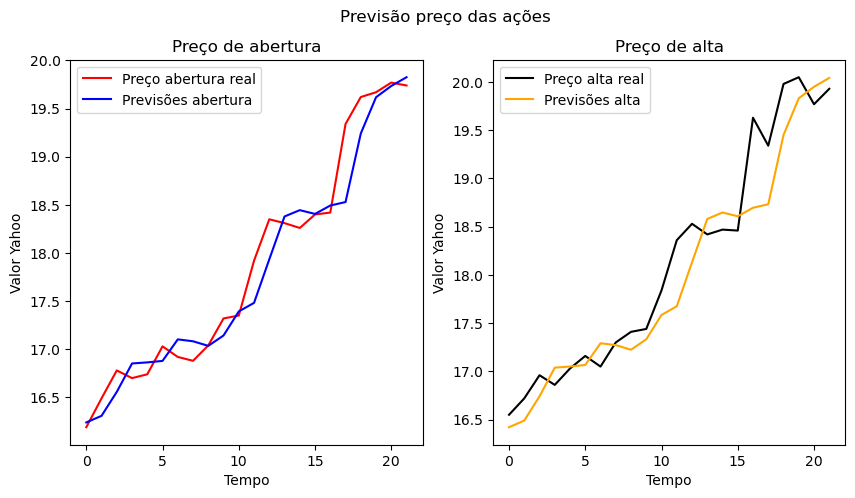

In [60]:
fig, ax = plt.subplots(1, 2, figsize = (10, 5))
fig.suptitle('Previsão preço das ações')

ax[0].plot(base_teste['Open'], color = 'red', label = 'Preço abertura real')
ax[0].plot(previsoes[:, 0], color = 'blue', label = 'Previsões abertura')
ax[0].set_title('Preço de abertura')
ax[0].set_xlabel('Tempo')
ax[0].set_ylabel('Valor Yahoo')
ax[0].legend()

ax[1].plot(base_teste['High'], color = 'black', label = 'Preço alta real')
ax[1].plot(previsoes[:, 1], color = 'orange', label = 'Previsões alta')
ax[1].set_title('Preço de alta')
ax[1].set_xlabel('Tempo')
ax[1].set_ylabel('Valor Yahoo')
ax[1].legend()